In [1]:
import xarray as xr
import numpy as np
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from shapely.geometry import box
import shapely.vectorized as sv
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def average_capacity_factors(filename):
    '''
    Function to read in a .nc file and calculate the average capacity factors over time.
    '''
    ds = xr.open_dataset(filename)

    cf_avg = ds.mean(dim='time')

    return cf_avg

def get_top_60_percent_cfs(avg_capacity_factors):
    '''
    Function to get the top 60% of capacity factors.
    '''
    # quantile(skipna=True) only looks at non-NaN cells in avg_capacity_factors --
    # so if this was clipped to a zone (e.g. LRZ1) upstream, only that zone's
    # cells are considered here, not the full MISO grid
    cfs_60 = avg_capacity_factors.where(avg_capacity_factors > avg_capacity_factors.quantile(0.01, skipna=True), -1)

    # Assuming 'variable_name' is the name of the variable in the Dataset
    num_cfs_60 = cfs_60['capacity factor'].where(cfs_60['capacity factor'] != -1).notnull().sum().item()
    print(f"Number of grid cells in the top 60%: {num_cfs_60}/{cfs_60['capacity factor'].size}")

    return cfs_60

In [3]:
def get_time_series_top_60_percent_cfs(filename, cfs_60, cf_type):
    '''
    Function to get the time series of the top 60% of capacity factors.
    '''
    ds = xr.open_dataset(filename)

    # Save average over all grid cells to csv file
    ds_avg = ds.mean(dim=['x', 'y'])
    ds_avg_df = ds_avg.to_dataframe()
    ds_avg_df = ds_avg_df.rename(columns={'capacity factor': f'{cf_type}_cf_avg'})
    year = filename.split('_')[-1].split('.')[0]
    # ds_avg_df.to_csv(f'CONUS_{cf_type}_CF_avg_all_{year}.csv')

    # Get time series of top 60% grid cells
    cfs_60_ts = ds.where(cfs_60 > 0)

    # Average over all grid cells
    cfs_60_ts = cfs_60_ts.mean(dim=['x', 'y'])

    # Write to csv file
    cfs_60_df = cfs_60_ts.to_dataframe()

    # Drop columns execpt for time and capacity factor
    cfs_60_df = cfs_60_df.drop(columns=['quantile'])
    # Rename columns
    cfs_60_df = cfs_60_df.rename(columns={'capacity factor': f'{cf_type}_cf'})

    # Write to csv file
    year = filename.split('_')[-1].split('.')[0]
    cfs_60_df.to_csv(f'CONUS_{cf_type}_CF_{year}.csv')

In [4]:
def plot_capacity_factor(cf, cap_fac_type):
    '''
    Function to plot the capacity factor over the MISO region, with US
    state boundaries overlaid (instead of the MISO cluster/zone geojsons)
    so viewers can see state lines on the map.
    '''
    from shapely.validation import make_valid

    miso = gpd.read_file("/Users/mshaaban/clab_underground_th_storage/maping/1/1.geojson")
    if miso.crs is None or miso.crs.to_epsg() != 4326:
        miso = miso.to_crs(epsg=4326)
    #miso_geom = miso.geometry.union_all()

        # Fix invalid geometries
    miso["geometry"] = miso["geometry"].apply(make_valid)
    miso_geom = miso.geometry.union_all()

    lon, lat = np.meshgrid(cf['x'], cf['y'])
    mask = sv.contains(miso_geom, lon, lat)
    masked_dataset = cf.where(mask)

    aspect_ratio = (cf['x'].max()-cf['x'].min())/(cf['y'].max()-cf['y'].min())

    # Create the figure/axes ourselves (instead of letting xarray's .plot()
    # do it) so we have an `ax` to draw the state boundaries on top of
    fig, ax = plt.subplots(figsize=(5*float(aspect_ratio), 5))
    masked_dataset["capacity factor"].plot(ax=ax, vmin=0.)

    # Overlay US state boundaries (Natural Earth 1:10m states/provinces),
    # cropped to the plotted extent so we only draw the states that
    # actually fall within the MISO footprint being shown.
    # 10m resolution (vs 50m) is used because 50m oversimplifies
    # shoreline-defined borders like Michigan's, which is bounded almost
    # entirely by the Great Lakes -- 50m renders that as blocky/odd-looking,
    # while 10m tracks the true coastline much more closely.
    states_path = shpreader.natural_earth(
        resolution="10m", category="cultural", name="admin_1_states_provinces"
    )
    states = gpd.read_file(states_path)
    states = states[states["admin"] == "United States of America"]
    if states.crs is None or states.crs.to_epsg() != 4326:
        states = states.to_crs(epsg=4326)

    xmin, xmax = float(cf["x"].min()), float(cf["x"].max())
    ymin, ymax = float(cf["y"].min()), float(cf["y"].max())
    states.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(f'{cap_fac_type} MISO average')
    fig.savefig(f'capacity_factor_MISO_{cap_fac_type.replace(" ","").replace("%","")}.jpg')
    print(masked_dataset["capacity factor"].where(masked_dataset["capacity factor"] > 0).mean().values)


In [5]:
def clip_dataset_to_zone(ds, zone_geojson_path):
    """
    Actually shrink an xarray Dataset down to the grid cells inside a zone
    polygon (e.g. LRZ1), instead of just masking values to NaN.

    A plain .where(mask) keeps every grid cell in the array -- it just sets
    the excluded ones to NaN, so array.size (and any "X out of Y grid cells"
    count) never changes no matter what geometry you mask with. This trims
    the 'x'/'y' coordinate arrays down to the zone's bounding box first, so
    the resulting dataset's actual shape shrinks, then masks the remaining
    cells that still fall outside the polygon (bounding boxes aren't exact
    for irregular zone shapes).
    """
    from shapely.validation import make_valid

    zone = gpd.read_file(zone_geojson_path)
    if zone.crs is None or zone.crs.to_epsg() != 4326:
        zone = zone.to_crs(epsg=4326)
    zone["geometry"] = zone["geometry"].apply(make_valid)
    zone_geom = zone.geometry.union_all()

    minx, miny, maxx, maxy = zone_geom.bounds

    # x/y coords can be ascending or descending -- .sel(slice(...)) needs the
    # slice to go the same direction as the coordinate array or it returns empty
    x_vals = ds['x'].values
    y_vals = ds['y'].values
    x_slice = slice(minx, maxx) if x_vals[0] < x_vals[-1] else slice(maxx, minx)
    y_slice = slice(miny, maxy) if y_vals[0] < y_vals[-1] else slice(maxy, miny)

    ds_clip = ds.sel(x=x_slice, y=y_slice)

    if ds_clip['x'].size == 0 or ds_clip['y'].size == 0:
        raise ValueError(
            "Clipping produced an empty grid -- check that the zone geojson's "
            "CRS/bounds actually overlap the .nc file's x/y coordinates."
        )

    # Bounding box isn't exact for irregular polygons, so also null out the
    # handful of remaining cells whose centers fall outside the actual shape
    lon, lat = np.meshgrid(ds_clip['x'], ds_clip['y'])
    mask = sv.contains(zone_geom, lon, lat)
    ds_clip = ds_clip.where(mask)

    print(f"Clipped grid: {ds_clip['x'].size} x cells x {ds_clip['y'].size} y cells "
          f"= {ds_clip['x'].size * ds_clip['y'].size} total (vs {ds['x'].size * ds['y'].size} before clipping)")

    return ds_clip

In [6]:
import os

base_dir = "/Users/mshaaban/clab_underground_th_storage/maping"

# Folder name on disk (with commas) -> geojson filename inside it (commas removed)
clusters = ["1", "2,7", "8,9,10", "6", "3,5", "4"]

def cluster_geojson_path(cluster, base_dir=base_dir):
    filename = cluster.replace(",", "") + ".geojson"
    return os.path.join(base_dir, cluster, filename)

cluster_paths = {cluster: cluster_geojson_path(cluster) for cluster in clusters}
for cluster, path in cluster_paths.items():
    print(f"{cluster:>10} -> {path}")

         1 -> /Users/mshaaban/clab_underground_th_storage/maping/1/1.geojson
       2,7 -> /Users/mshaaban/clab_underground_th_storage/maping/2,7/27.geojson
    8,9,10 -> /Users/mshaaban/clab_underground_th_storage/maping/8,9,10/8910.geojson
         6 -> /Users/mshaaban/clab_underground_th_storage/maping/6/6.geojson
       3,5 -> /Users/mshaaban/clab_underground_th_storage/maping/3,5/35.geojson
         4 -> /Users/mshaaban/clab_underground_th_storage/maping/4/4.geojson


In [7]:
def get_60_percent_cf_all(cf_type, zone_geojson_path=None):
    """
    Get the top 60% capacity factors for all years.

    If zone_geojson_path is given (e.g. your LRZ1 shapefile/geojson), each
    .nc file is clipped down to just that zone's grid cells immediately
    after it's opened -- so averaging, the top-X% cutoff, plotting, and the
    output time series all operate on the smaller zone-only grid rather than
    the full MISO footprint.

    Every plot produced here overlays US state boundaries (handled inside
    plot_capacity_factor) so viewers can see state lines regardless of
    whether the data was clipped to a single zone or run on the full
    MISO footprint.
    """

    def load_and_clip(year):
        ds = xr.open_dataset(f'miso_{cf_type}_CF_timeseries_{year}.nc')
        if zone_geojson_path is not None:
            ds = clip_dataset_to_zone(ds, zone_geojson_path)
        return ds

    cf_avg_2020 = load_and_clip(2020).mean(dim='time')
    cf_avg_2021 = load_and_clip(2021).mean(dim='time')
    cf_avg_2022 = load_and_clip(2022).mean(dim='time')
    cf_avg_2024 = load_and_clip(2024).mean(dim='time')
    cf_avg_2023 = load_and_clip(2023).mean(dim='time')

    cf_avg_all = (cf_avg_2020 + cf_avg_2021 + cf_avg_2022 + cf_avg_2023 + cf_avg_2024)/5

    # Plot
    plot_capacity_factor(cf_avg_all, cf_type)
    cf_all_60 = get_top_60_percent_cfs(cf_avg_all)
    plot_capacity_factor(cf_all_60, cf_type+" top 60%")

    cfs = []
    for year in range(2020, 2025):

        cf_ts = load_and_clip(year)

        # Only keep the capacity factors that are non-zero in cf_all_60
        cf_ts = cf_ts.where(cf_all_60 > -1)

        # Average over all grid cells
        cf_ts = cf_ts.mean(dim=['x', 'y'])

        cfs.append(cf_ts)

    cf_ts_all = xr.concat(cfs, dim='time')
    # Drop quantile dimension
    cf_ts_all = cf_ts_all.drop_vars('quantile', errors='ignore')
    # Rename capacity factor dimension
    cf_ts_all = cf_ts_all.rename({'capacity factor': f'{cf_type}_cf'})
    # Write to csv file
    cf_ts_all_df = cf_ts_all.to_dataframe()
    if zone_geojson_path is None:
        suffix = ""
    else:
        import os
        zone_name = os.path.splitext(os.path.basename(zone_geojson_path))[0]
        suffix = f"_{zone_name}"
    cf_ts_all_df.to_csv(f'MISO_{cf_type}_CF_2020_2024{suffix}.csv')


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_28847/2915499261.py:19: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.21771364907153054
Number of grid cells in the top 60%: 7918/7998


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_28847/2915499261.py:19: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.21771364907153054


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_28847/2915499261.py:19: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.43142856331875384
Number of grid cells in the top 60%: 7918/7998


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_28847/2915499261.py:19: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.43142856331875384


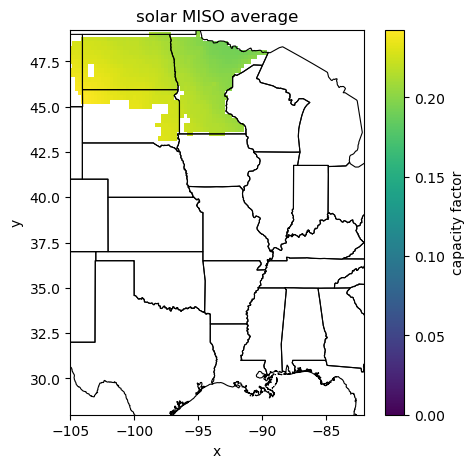

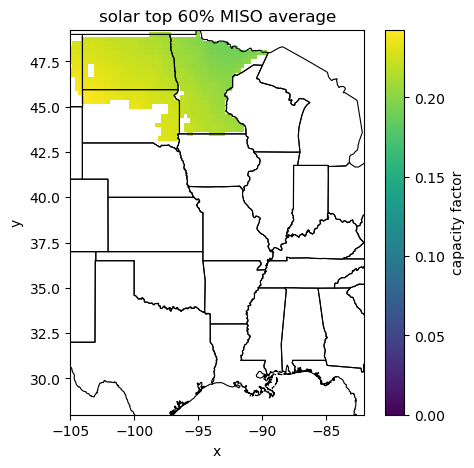

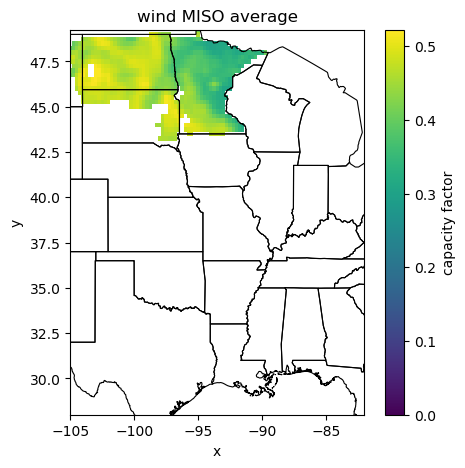

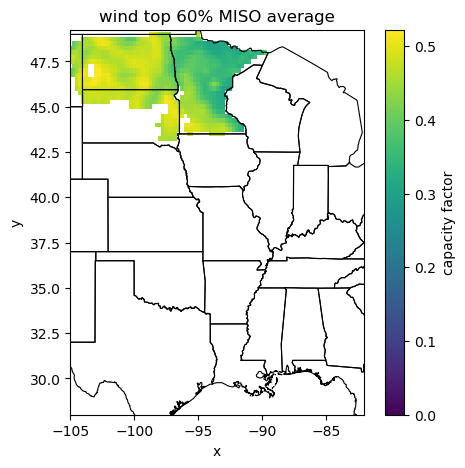

In [8]:
# Run on the whole (unclipped) MISO footprint. State boundaries are
# overlaid automatically inside plot_capacity_factor.
all_cluster_paths = list(cluster_paths.values())
get_60_percent_cf_all('solar')
get_60_percent_cf_all('wind')


In [9]:
def read_csv_file(filename):
    """
    Read csv file
    """
    df = pd.read_csv(filename)
    # Print mean of columm 1
    print(df.iloc[:,1].mean())

# Source for reported capacity factors:
# https://www.eia.gov/electricity/monthly/epm_table_grapher.php?t=table_6_07_b
print("Solar")
print("Reported 5 year average of capacity factors")
print((20.38+22.26+23.03+22.83+21.81)/5./100.)
print("Mean capacity factor of top 60% of grid cells")
read_csv_file('MISO_solar_CF_2020_2024.csv')

print("\n")
print("Wind")
print("Reported 5 year average of capacity factors")
print((31.66+32.13+36.65+31.76+33.15)/5./100.)
print("Mean capacity factor of top 60% of grid cells")
read_csv_file('MISO_wind_CF_2020_2024.csv')

Solar
Reported 5 year average of capacity factors
0.22062
Mean capacity factor of top 60% of grid cells
0.22075546090601247


Wind
Reported 5 year average of capacity factors
0.3307
Mean capacity factor of top 60% of grid cells
0.35664698415128343


## Batch: run all clusters at once

Runs the solar/wind top-60% pipeline for every cluster below, then builds
one combined summary table from the resulting CSVs.

(`cluster_paths` was already defined above so it could be used for the
zone-boundary overlay on the whole-MISO plots.)


=== Processing cluster 1 ===


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_28847/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


Clipped grid: 70 x cells x 34 y cells = 2380 total (vs 7998 before clipping)


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_28847/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


Clipped grid: 70 x cells x 34 y cells = 2380 total (vs 7998 before clipping)


...

/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_28847/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


Clipped grid: 70 x cells x 34 y cells = 2380 total (vs 7998 before clipping)


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_28847/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


Clipped grid: 70 x cells x 34 y cells = 2380 total (vs 7998 before clipping)

=== Processing cluster 2,7 ===


DataSourceError: /Users/mshaaban/clab_underground_th_storage/maping/2,7/27.geojson: No such file or directory

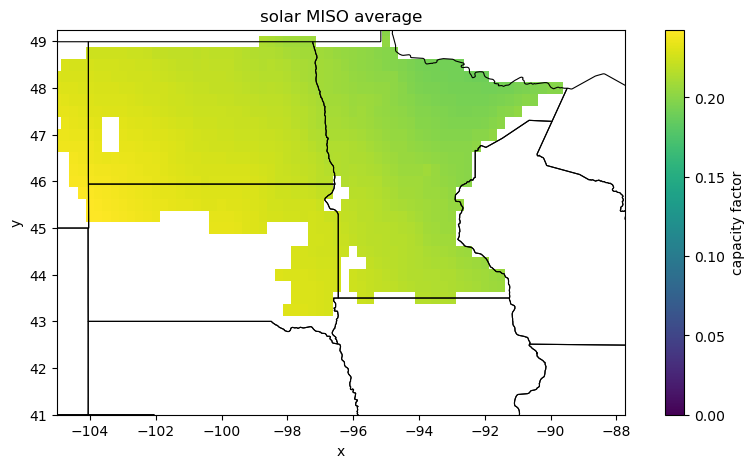

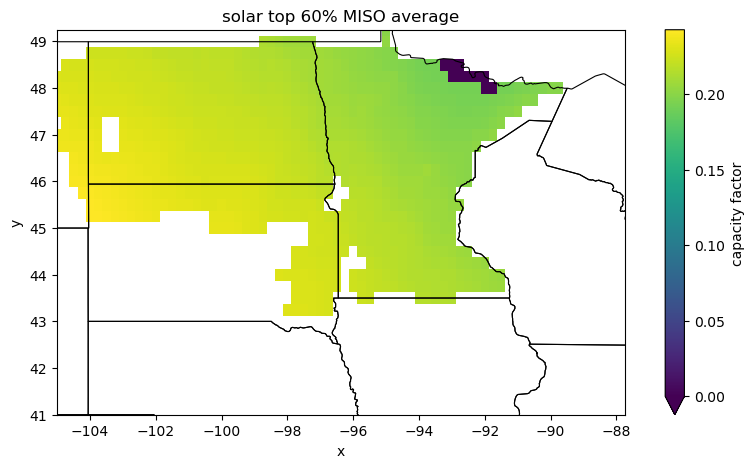

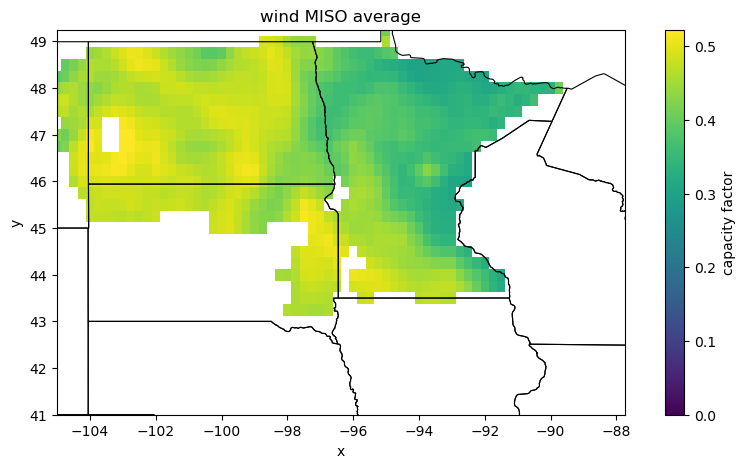

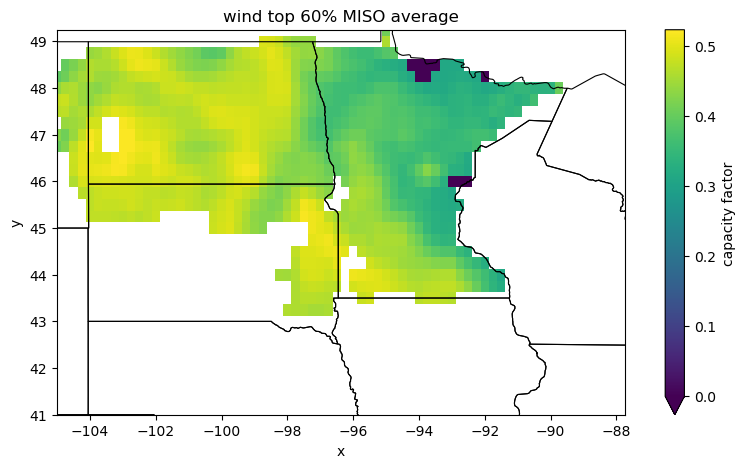

In [10]:
# Run the full solar + wind pipeline for every cluster.
# This writes MISO_solar_CF_2020_2024_<clusterfile>.csv and
# MISO_wind_CF_2020_2024_<clusterfile>.csv for each one, using the
# suffix convention from get_60_percent_cf_all.
for cluster, path in cluster_paths.items():
    print(f"\n=== Processing cluster {cluster} ===")
    get_60_percent_cf_all('solar', zone_geojson_path=path)
    get_60_percent_cf_all('wind', zone_geojson_path=path)

In [ ]:
def summarize_all_clusters(cluster_paths):
    """
    Build one summary table of mean solar/wind capacity factor (top 60% of
    grid cells) across all clusters, reading back the CSVs that
    get_60_percent_cf_all just wrote.
    """
    rows = []
    for cluster, path in cluster_paths.items():
        suffix = f"_{os.path.splitext(os.path.basename(path))[0]}"
        solar_df = pd.read_csv(f'MISO_solar_CF_2020_2024{suffix}.csv')
        wind_df = pd.read_csv(f'MISO_wind_CF_2020_2024{suffix}.csv')
        rows.append({
            "cluster": cluster,
            "solar_cf_mean": solar_df.iloc[:, 1].mean(),
            "wind_cf_mean": wind_df.iloc[:, 1].mean(),
        })
    return pd.DataFrame(rows)

summary = summarize_all_clusters(cluster_paths)
summary